In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/rgukt/Desktop/Electricity-Demand-Forecasting-Dashboard/PJME_hourly.csv")

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [2]:
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [3]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values("Datetime")

df.head()

,Datetime,PJME_MW
8734,2002-01-01 01:00:00,30393.0
8735,2002-01-01 02:00:00,29265.0
8736,2002-01-01 03:00:00,28357.0
8737,2002-01-01 04:00:00,27899.0
8738,2002-01-01 05:00:00,28057.0


In [4]:
df.rename(columns={"PJME_MW":"demand"},inplace=True)

In [5]:
df.head()

,Datetime,demand
8734,2002-01-01 01:00:00,30393.0
8735,2002-01-01 02:00:00,29265.0
8736,2002-01-01 03:00:00,28357.0
8737,2002-01-01 04:00:00,27899.0
8738,2002-01-01 05:00:00,28057.0


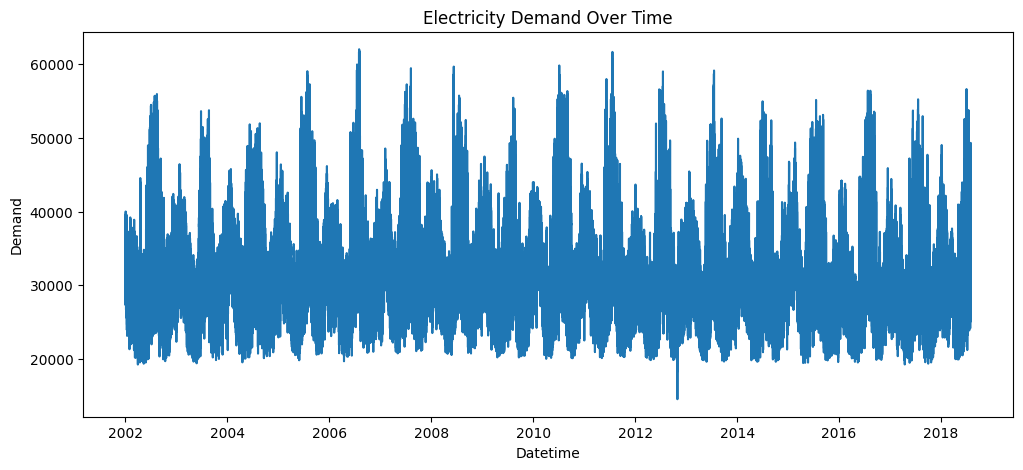

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['demand'])

plt.title("Electricity Demand Over Time")
plt.xlabel("Datetime")
plt.ylabel("Demand")
plt.show()

In [7]:
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month

In [8]:
df.head(30)

,Datetime,demand,hour,dayofweek,month
8734,2002-01-01 01:00:00,30393.0,1,1,1
8735,2002-01-01 02:00:00,29265.0,2,1,1
8736,2002-01-01 03:00:00,28357.0,3,1,1
8737,2002-01-01 04:00:00,27899.0,4,1,1
8738,2002-01-01 05:00:00,28057.0,5,1,1
8739,2002-01-01 06:00:00,28654.0,6,1,1
8740,2002-01-01 07:00:00,29308.0,7,1,1
8741,2002-01-01 08:00:00,29595.0,8,1,1
8742,2002-01-01 09:00:00,29943.0,9,1,1
8743,2002-01-01 10:00:00,30692.0,10,1,1


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(df[['demand','hour','dayofweek','month']])

In [10]:
import numpy as np

def create_sequences(data, seq_length):

    x = []
    y = []

    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])

    return np.array(x), np.array(y)


seq_length = 24

x, y = create_sequences(data_scaled, seq_length)

In [11]:
split = int(0.8 * len(x))

xtrain = x[:split]
xtest = x[split:]

ytrain = y[:split]
ytest = y[split:]

In [12]:
split = int(0.8 * len(x))

xtrain = x[:split]
xtest = x[split:]

ytrain = y[:split]
ytest = y[split:]

In [13]:
%pip install tensorflow==2.12.0

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.12.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.4.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached grpcio-1.70.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.9 kB)
  Using cached h5py-3.11.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.5 kB)
  Using cached jax-0.4.13.tar.gz (1.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached keras-2.12.0-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached libcla

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(24,4)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dense(16, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

2026-09-11 17:27:38.708218: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-11 17:27:39.073669: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-11 17:27:39.074943: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-11 17:27:41.322827: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-09-11 17:27:47.009612: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 64)            17664     
                                                                 
 dropout (Dropout)           (None, 24, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 30,625
Trainable params: 30,625
Non-trainable params: 0
_________________________________________________________________


2026-09-11 17:27:47.380217: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-09-11 17:27:47.383464: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-09-11 17:27:47.385703: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [15]:
model.fit(
    xtrain,
    ytrain,
    epochs=20,
    batch_size=32,
    validation_data=(xtest,ytest)
)

Epoch 1/20


2026-09-11 17:27:48.677819: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-09-11 17:27:48.681141: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-09-11 17:27:48.683508: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3634/3634 [==============================] - ETA: 0s - loss: 0.0016

2026-09-11 17:29:32.646819: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-09-11 17:29:32.650082: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-09-11 17:29:32.652491: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3634/3634 [==============================] - 115s 30ms/step - loss: 0.0016 - val_loss: 4.6968e-04
Epoch 2/20
3634/3634 [==============================] - 108s 30ms/step - loss: 2.9808e-04 - val_loss: 1.4991e-04
Epoch 3/20
3634/3634 [==============================] - 108s 30ms/step - loss: 1.8808e-04 - val_loss: 9.6873e-05
Epoch 4/20
3634/3634 [==============================] - 108s 30ms/step - loss: 1.4944e-04 - val_loss: 8.6754e-05
Epoch 5/20
3634/3634 [==============================] - 108s 30ms/step - loss: 1.2404e-04 - val_loss: 9.8193e-05
Epoch 6/20
3634/3634 [==============================] - 108s 30ms/step - loss: 1.1216e-04 - val_loss: 7.1734e-05
Epoch 7/20
3634/3634 [==============================] - 108s 30ms/step - loss: 1.0247e-04 - val_loss: 5.2102e-05
Epoch 8/20
3634/3634 [==============================] - 108s 30ms/step - loss: 9.1776e-05 - val_loss: 4.7560e-05
Epoch 9/20
3634/3634 [==============================] - 111s 30ms/step - loss: 8.6385e-05 - val_loss: 5.6098e-0

In [16]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(xtest)

mae = mean_absolute_error(ytest, pred)

print("MAE:", mae)

2026-09-11 18:05:34.275339: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-09-11 18:05:34.278709: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-09-11 18:05:34.281073: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

909/909 [==============================] - 11s 11ms/step
MAE: 0.004956598909417713


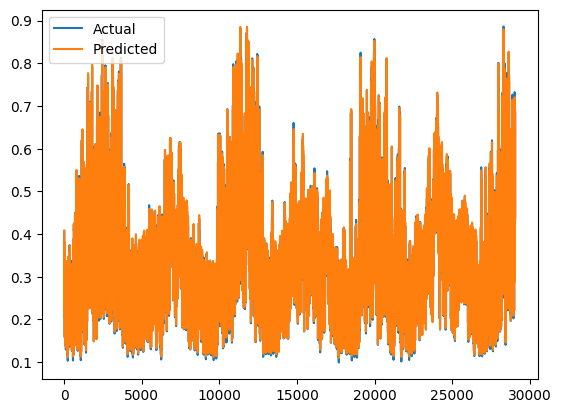

In [18]:
import matplotlib.pyplot as plt

plt.plot(ytest,label="Actual")
plt.plot(pred,label="Predicted")

plt.legend()
plt.show()

In [19]:
model.save("models/electricity_lstm_model.h5")

/home/pardhasaradhi/projects/NueralNetworks/venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
import pickle

pickle.dump(scaler, open("models/scaler.pkl","wb"))

In [ ]:
sample = xtest[0].reshape(1,24,6)

pred = model.predict(sample)

print(pred)

TypeError: in user code:

    File "/home/pardhasaradhi/projects/NueralNetworks/venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 2440, in predict_function  *
        return step_function(self, iterator)
    File "/home/pardhasaradhi/projects/NueralNetworks/venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 2425, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/pardhasaradhi/projects/NueralNetworks/venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 2413, in run_step  **
        outputs = model.predict_step(data)
    File "/home/pardhasaradhi/projects/NueralNetworks/venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 2381, in predict_step
        return self(x, training=False)
    File "/home/pardhasaradhi/projects/NueralNetworks/venv/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceba

In [23]:
xtrain.shape

(116273, 24, 4)

In [24]:
print(df['demand'].min())
print(df['demand'].max())
print(df['demand'].mean())

14544.0
62009.0
32080.222830648156
